<a href="https://colab.research.google.com/github/nicknaamee/Red_Neuronal_MLP/blob/main/Evaluacion_BankMarketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Red Neuronal Multicapa (MLP) para clasificación
## Dataset: *Bank Marketing* (UCI Machine Learning Repository)

### Contexto del problema

Un banco portugués realizó **campañas de marketing telefónico** para ofrecer a sus clientes un **depósito a plazo**. Por cada cliente contactado se registraron sus datos personales, su situación financiera y el historial de contactos de la campaña.

**Objetivo:** construir un modelo que prediga si un cliente **contratará el depósito a plazo** (`y = "yes"`) o **no** (`y = "no"`).

| | |
|---|---|
| **Tipo de problema** | Clasificación **binaria** |
| **Registros** | 45.211 clientes |
| **Variables de entrada** | 16 (7 numéricas y 9 categóricas) |
| **Variable objetivo** | `y` ("yes" / "no") |
| **Fuente** | [UCI Machine Learning Repository — Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) |
| **Licencia** | CC BY 4.0 |
| **Cita** | Moro, S., Cortez, P. & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems, 62, 22–31. |

## ¿Qué deben demostrar?

1. Cargar y **preprocesar** correctamente los datos.
2. **Diseñar e implementar** una arquitectura MLP (TensorFlow/Keras o PyTorch).
3. Configurar **parámetros de entrenamiento**: épocas, tasa de aprendizaje y tamaño de batch.
4. **Comparar** distintas funciones de **activación** y funciones de **pérdida**.
5. Aplicar técnicas de **optimización** y **regularización**.
6. **Evaluar** el desempeño con **Accuracy, Precision, Recall y F1-Score**.
7. **Analizar** los resultados y **justificar** las mejoras realizadas al modelo.

> Este notebook **solo carga y describe los datos**. Todo el preprocesamiento, el modelo y el análisis son parte de su trabajo.

## 1. Cargar los datos

Ejecuta **una** de las dos opciones.

**Opción A (recomendada): descarga directa desde UCI.** Funciona en Google Colab y en Jupyter local. Solo requiere internet.

In [ ]:
import io
import zipfile
import urllib.request

import pandas as pd
import matplotlib.pyplot as plt

URL_UCI = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

with urllib.request.urlopen(URL_UCI) as resp:
    zip_externo = zipfile.ZipFile(io.BytesIO(resp.read()))
zip_interno = zipfile.ZipFile(io.BytesIO(zip_externo.read("bank.zip")))   # el archivo viene comprimido dos veces
df = pd.read_csv(zip_interno.open("bank-full.csv"), sep=";")

print("Datos cargados:", df.shape[0], "filas x", df.shape[1], "columnas")

Datos cargados: 45211 filas x 17 columnas


**Opción B: desde el archivo `bank_marketing.csv` entregado por el docente.**

- **En Colab:** sube el archivo con el ícono de carpeta (panel izquierdo → *Subir*) y ejecuta la celda.
- **En Jupyter local:** deja el CSV en la misma carpeta que este notebook.
- **Desde un enlace** (Google Drive / GitHub): pega el enlace en `ENLACE`. Si es de Google Drive, el archivo debe estar compartido como *"Cualquier persona con el enlace"*.

In [ ]:
ENLACE = ""   # opcional: pega aquí el enlace entregado por el docente

def enlace_descarga(url):
    # Convierte un enlace "compartir" de Google Drive en un enlace de descarga directa
    if "drive.google.com" in url and "/d/" in url:
        file_id = url.split("/d/")[1].split("/")[0]
        return f"https://drive.google.com/uc?export=download&id={file_id}"
    return url

df = pd.read_csv(enlace_descarga(ENLACE) if ENLACE else "bank_marketing.csv")
print("Datos cargados:", df.shape[0], "filas x", df.shape[1], "columnas")

## 2. Diccionario de variables

**Datos del cliente**

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | numérica | Edad |
| `job` | categórica | Tipo de trabajo (`admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`) |
| `marital` | categórica | Estado civil (`married`, `single`, `divorced` — "divorced" incluye viudos) |
| `education` | categórica | Nivel educacional (`primary`, `secondary`, `tertiary`, `unknown`) |
| `default` | binaria | ¿Tiene créditos en mora? (`yes` / `no`) |
| `balance` | numérica | Saldo promedio anual, en euros (puede ser negativo) |
| `housing` | binaria | ¿Tiene crédito hipotecario? |
| `loan` | binaria | ¿Tiene crédito de consumo? |

**Último contacto de la campaña actual**

| Variable | Tipo | Descripción |
|---|---|---|
| `contact` | categórica | Medio de contacto (`cellular`, `telephone`, `unknown`) |
| `day` | numérica | Día del mes del último contacto |
| `month` | categórica | Mes del último contacto (`jan` … `dec`) |
| `duration` | numérica | Duración del último contacto, en segundos ⚠️ *(ver nota importante más abajo)* |

**Otros atributos**

| Variable | Tipo | Descripción |
|---|---|---|
| `campaign` | numérica | N° de contactos realizados a este cliente en esta campaña (incluye el último) |
| `pdays` | numérica | Días transcurridos desde el último contacto de una campaña **anterior** (`-1` = nunca fue contactado antes) |
| `previous` | numérica | N° de contactos realizados antes de esta campaña |
| `poutcome` | categórica | Resultado de la campaña anterior (`success`, `failure`, `other`, `unknown`) |

**Variable objetivo**

| Variable | Tipo | Descripción |
|---|---|---|
| `y` | binaria | ¿El cliente contrató el depósito a plazo? (`yes` / `no`) |

## 3. Primera mirada a los datos

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


### Distribución de la variable objetivo

,cantidad,porcentaje (%)
y,,
no,39922,88.3
yes,5289,11.7


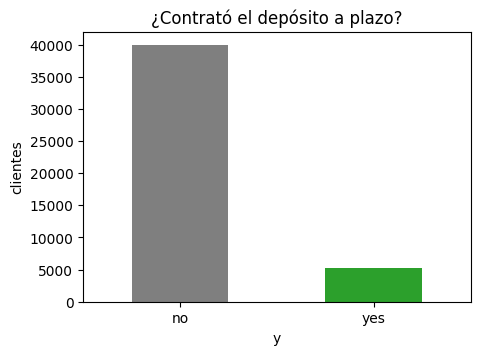

In [ ]:
conteo = df["y"].value_counts()
porcentaje = df["y"].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({"cantidad": conteo, "porcentaje (%)": porcentaje}))

conteo.plot(kind="bar", color=["tab:gray", "tab:green"], figsize=(5, 3.5), rot=0,
            title="¿Contrató el depósito a plazo?")
plt.ylabel("clientes")
plt.show()

### Valores "unknown"

El dataset **no tiene celdas vacías**, pero varias columnas categóricas usan el texto `"unknown"` cuando no se conoce el dato.

In [ ]:
print("Celdas vacías (NaN):", df.isna().sum().sum())
categoricas = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype) == "str"]
unknown = {c: int((df[c] == "unknown").sum()) for c in categoricas}
pd.Series(unknown, name="cantidad de 'unknown'").to_frame().query("`cantidad de 'unknown'` > 0")

Celdas vacías (NaN): 0


,cantidad de 'unknown'
job,288
education,1857
contact,13020
poutcome,36959


## 4. Consideraciones importantes

1. **Clases desbalanceadas.** Solo ~12 % de los clientes contrató el depósito. Un modelo que responda siempre `"no"` obtiene **~88 % de Accuracy** sin haber aprendido nada. Por eso **Precision, Recall y F1-Score** de la clase `"yes"` son fundamentales para evaluar los modelos.
2. **La variable `duration`.** La duración de la llamada solo se conoce **después** de hacerla, y cuando `duration = 0` el resultado siempre es `"no"`. Los autores del dataset recomiendan **no usarla** si el objetivo es un modelo predictivo realista (uno que se use *antes* de llamar al cliente). Decidan si la incluyen o no y **justifiquen** su decisión en el análisis.
3. **Variables categóricas.** La red neuronal necesita números: hay que transformar las variables de texto.
4. **Escalas muy distintas.** Por ejemplo, `balance` va de miles de euros negativos a más de 100.000, mientras que `previous` suele estar entre 0 y 5.
5. **`pdays = -1`** no es un número de días: significa "nunca contactado antes".
6. **Separación de datos.** Todo lo que el preprocesamiento "aprende" (medias, escalas, categorías) debe calcularse **solo con los datos de entrenamiento**.

## 5. Su trabajo comienza aquí ⬇️

Sugerencia de estructura para el notebook de entrega:

1. Análisis exploratorio y preprocesamiento
2. Separación en entrenamiento / validación / prueba
3. Modelo base (MLP) y configuración de entrenamiento
4. Comparación de funciones de activación y de pérdida
5. Optimización y regularización
6. Evaluación final: Accuracy, Precision, Recall, F1-Score y matriz de confusión
7. Análisis de resultados y justificación de las mejoras

### 1. Preprocesamiento de Datos

**Justificación técnica:**
*   **Data Leakage:** Eliminamos la columna `duration` tal como recomienda la documentación, ya que en un escenario de predicción real no conocemos cuánto durará la llamada antes de realizarla.
*   **División:** Separamos en Train (70%), Validación (15%) y Prueba (15%) de forma estratificada para evaluar la generalización del modelo sin caer en *overfitting*.
*   **Transformaciones:** Aplicamos `StandardScaler` a las variables numéricas y `OneHotEncoder` a las categóricas. Es vital hacer el `fit` exclusivamente en el set de Entrenamiento para prevenir filtración de datos hacia los sets de prueba.
*   **Desbalanceo:** Calculamos *class weights* para compensar la baja proporción de clientes que contratan el depósito (clase "yes"), forzando al modelo a penalizar más los errores en esta clase minoritaria.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight

# 1. Copia y limpieza (Eliminar duration)
df_model = df.copy()
df_model = df_model.drop(columns=['duration'])

# 2. Separar predictoras (X) de etiqueta (y)
X = df_model.drop(columns=['y'])
y = df_model['y'].map({'yes': 1, 'no': 0})

# 3. División: 70% Entrenamiento, 15% Validación, 15% Prueba
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# 4. Transformadores (Escalamiento numérico y Codificación categórica)
cols_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_cat = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), cols_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_cat)
])

# Ajustar transformador SOLO con Train y luego aplicarlo a Val y Test
X_train_t = preprocessor.fit_transform(X_train)
X_val_t  = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

# 5. Pesos para compensar el desbalanceo
pesos = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_clases = {0: pesos[0], 1: pesos[1]}

print(f"Set Entrenamiento listo: {X_train_t.shape}")
print(f"Set Validación listo   : {X_val_t.shape}")
print(f"Set Prueba listo       : {X_test_t.shape}")

Set Entrenamiento listo: (31647, 50)
Set Validación listo   : (6782, 50)
Set Prueba listo       : (6782, 50)


### 2. Preparación y Separación de Datos

**Justificación técnica:**
* **Eliminación de `duration`:** Se descarta esta variable para evitar *Data Leakage*, ya que en un escenario de negocio real no se conoce la duración de la llamada antes de realizarla.
* **Codificación de la variable objetivo:** La red neuronal requiere valores numéricos, por lo que transformamos `y` ("yes"/"no") a formato binario (1/0).
* **División Estratégica (70/15/15):**
  * **Entrenamiento (70%):** Utilizado para que el modelo ajuste sus pesos.
  * **Validación (15%):** Utilizado para evaluar el desempeño época a época y ajustar hiperparámetros (como *Early Stopping*) sin sesgar el modelo.
  * **Prueba (15%):** Datos completamente invisibles que se usarán únicamente al final para medir la capacidad real de generalización.
* **Estratificación (`stratify=y`):** Dado el fuerte desbalanceo de clases (~12% de "yes"), forzamos a que esta misma proporción se mantenga matemáticamente exacta en los tres conjuntos.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Copia de seguridad y eliminación de la variable 'duration'
df_model = df.copy()
df_model = df_model.drop(columns=['duration'])

# 2. Separación de variables predictoras (X) y variable objetivo (y)
X = df_model.drop(columns=['y'])
y = df_model['y'].map({'yes': 1, 'no': 0})

# 3. División del dataset
# Primero separamos el 70% para Entrenamiento y guardamos un 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Luego dividimos ese 30% temporal por la mitad (15% Validación, 15% Prueba)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Muestras para Entrenamiento : {X_train.shape[0]}")
print(f"Muestras para Validación    : {X_val.shape[0]}")
print(f"Muestras para Prueba        : {X_test.shape[0]}")

Muestras para Entrenamiento : 31647
Muestras para Validación    : 6782
Muestras para Prueba        : 6782


### 3. Modelo Base (MLP) y Configuración de Entrenamiento

**Justificación técnica:**
*   **Arquitectura Base:** Se diseña un Perceptrón Multicapa (MLP) inicial sin regularización (sin Dropout ni Batch Normalization) para establecer un modelo de referencia (baseline). Cuenta con dos capas ocultas dispuestas en embudo (64 y 32 neuronas) para extraer progresivamente los patrones numéricos del dataset.
*   **Funciones de Activación:** Las capas ocultas utilizan **ReLU** para prevenir el problema del desvanecimiento del gradiente y acelerar la convergencia. La capa de salida utiliza **Sigmoide**, comprimiendo el resultado en una probabilidad entre 0 y 1, lo cual es obligatorio para este problema de clasificación binaria ("yes" / "no").
*   **Optimizador y Pérdida:** Se implementa **Adam** con una tasa de aprendizaje inicial de 0.001, ya que adapta la velocidad de actualización de los pesos dinámicamente. La función de pérdida seleccionada es `binary_crossentropy`, el estándar matemático para clasificaciones de dos clases.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Fijar semilla de TensorFlow para asegurar reproducibilidad en los pesos iniciales
tf.random.set_seed(42)

def construir_mlp_base(learning_rate=0.001):
    # Inicializamos el modelo secuencial
    modelo = Sequential(name="MLP_Base")

    # 1° Capa Oculta: 64 neuronas. input_shape recibe la cantidad de características transformadas
    modelo.add(Dense(64, activation='relu', input_shape=(X_train_t.shape[1],), name="Capa_Oculta_1"))

    # 2° Capa Oculta: 32 neuronas
    modelo.add(Dense(32, activation='relu', name="Capa_Oculta_2"))

    # Capa de Salida: 1 neurona con activación sigmoide (clasificación binaria)
    modelo.add(Dense(1, activation='sigmoid', name="Capa_Salida"))

    # Configurar el optimizador Adam
    optimizador = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Compilar el modelo
    modelo.compile(
        optimizer=optimizador,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

# Instanciar el modelo base
modelo_base = construir_mlp_base()

# Visualizar la arquitectura y el total de parámetros a optimizar
modelo_base.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Comparación de Funciones de Activación y Pérdida (Error)

**Justificación técnica:**
Para validar la arquitectura base, someteremos el modelo a experimentos comparativos aislados:
*   **Funciones de Activación (Capas Ocultas):** Compararemos el rendimiento de **ReLU** frente a **Tanh** (Tangente Hiperbólica). Mientras ReLU mitiga el desvanecimiento del gradiente al no saturarse en valores positivos, Tanh centra los datos (entre -1 y 1), lo que en ciertos contextos estabiliza el aprendizaje, aunque sufre de saturación en los extremos.
*   **Funciones de Pérdida (Error):** Contrastaremos **Binary Crossentropy** (Entropía Cruzada Binaria) frente a **MSE** (Error Cuadrático Medio). La teoría demuestra que `binary_crossentropy` es superior para clasificación binaria porque penaliza logarítmicamente las predicciones incorrectas pero con alta confianza, acelerando la convergencia. MSE, aunque es el estándar en regresión, tiende a provocar un aprendizaje demasiado lento al inicio cuando se combina con la función sigmoide en la capa de salida.
*   **Diseño del Experimento:** Entrenaremos tres variantes del modelo durante 30 épocas (fijando el *batch_size* en 64 y el *learning rate* de Adam en 0.001) y evaluaremos las diferencias de desempeño utilizando gráficos de convergencia y una tabla comparativa de métricas clave.

Entrenando variante: ReLU + BCE ...
Entrenando variante: Tanh + BCE ...
Entrenando variante: ReLU + MSE ...


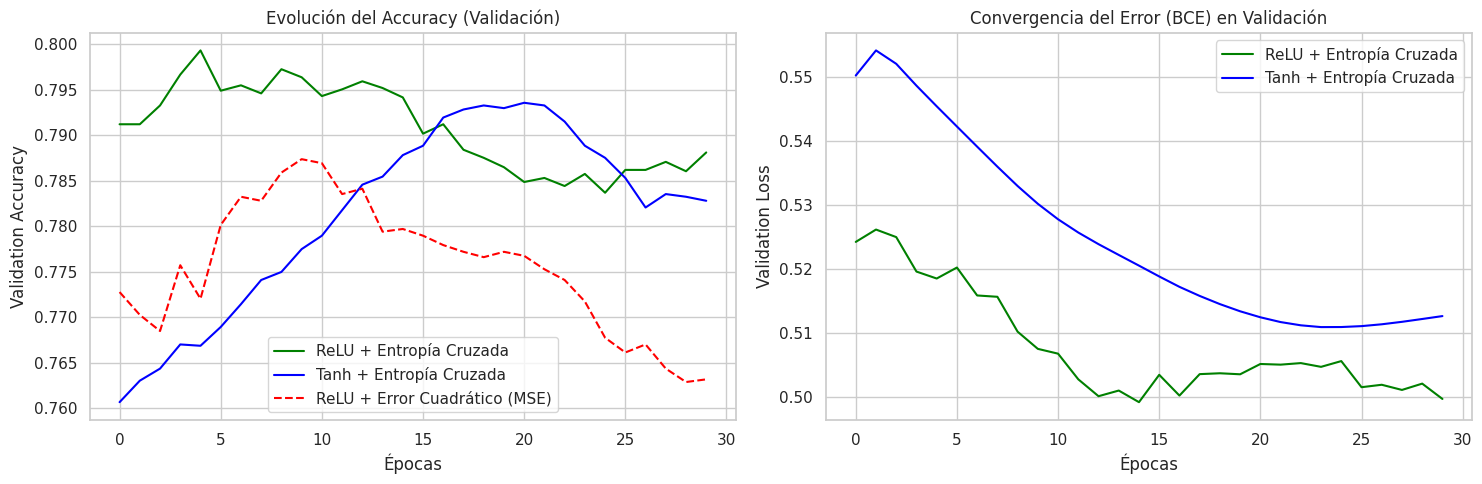

,Configuración,Loss Final (Train),Accuracy Final (Train),Loss Final (Val),Accuracy Final (Val)
0,ReLU + BCE,0.4611,0.7998,0.4997,0.7881
1,Tanh + BCE,0.4920,0.7989,0.5127,0.7828
2,ReLU + MSE,0.1485,0.8121,0.1749,0.7632


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

def entrenar_variante(activacion_oculta, funcion_perdida, nombre_display):
    # 1. LIMPIEZA DE MEMORIA: Borramos cualquier rastro de sesiones anteriores en Colab
    tf.keras.backend.clear_session()

    # 2. Creamos la red
    modelo = tf.keras.models.Sequential()
    modelo.add(tf.keras.layers.Dense(64, activation=activacion_oculta, input_shape=(X_train_t.shape[1],)))
    modelo.add(tf.keras.layers.Dense(32, activation=activacion_oculta))
    modelo.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=funcion_perdida,
        metrics=['accuracy']
    )

    print(f"Entrenando variante: {nombre_display} ...")
    historia = modelo.fit(
        X_train_t, y_train,
        validation_data=(X_val_t, y_val),
        epochs=30,
        batch_size=64,
        class_weight=pesos_clases,
        verbose=0
    )
    return historia

# --- 1. EJECUTAR EXPERIMENTOS ---
hist_relu_bce = entrenar_variante('relu', 'binary_crossentropy', 'ReLU + BCE')
hist_tanh_bce = entrenar_variante('tanh', 'binary_crossentropy', 'Tanh + BCE')
hist_relu_mse = entrenar_variante('relu', 'mse', 'ReLU + MSE')

# --- 2. GRÁFICOS COMPARATIVOS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Precisión (Accuracy)
axes[0].plot(hist_relu_bce.history['val_accuracy'], label='ReLU + Entropía Cruzada', color='green')
axes[0].plot(hist_tanh_bce.history['val_accuracy'], label='Tanh + Entropía Cruzada', color='blue')
axes[0].plot(hist_relu_mse.history['val_accuracy'], label='ReLU + Error Cuadrático (MSE)', color='red', linestyle='--')
axes[0].set_title('Evolución del Accuracy (Validación)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()

# Gráfico de Pérdida (Loss)
axes[1].plot(hist_relu_bce.history['val_loss'], label='ReLU + Entropía Cruzada', color='green')
axes[1].plot(hist_tanh_bce.history['val_loss'], label='Tanh + Entropía Cruzada', color='blue')
axes[1].set_title('Convergencia del Error (BCE) en Validación')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- 3. TABLA RESUMEN DE MÉTRICAS ---
resultados = {
    'Configuración': ['ReLU + BCE', 'Tanh + BCE', 'ReLU + MSE'],
    'Loss Final (Train)': [
        hist_relu_bce.history['loss'][-1],
        hist_tanh_bce.history['loss'][-1],
        hist_relu_mse.history['loss'][-1]
    ],
    'Accuracy Final (Train)': [
        hist_relu_bce.history['accuracy'][-1],
        hist_tanh_bce.history['accuracy'][-1],
        hist_relu_mse.history['accuracy'][-1]
    ],
    'Loss Final (Val)': [
        hist_relu_bce.history['val_loss'][-1],
        hist_tanh_bce.history['val_loss'][-1],
        hist_relu_mse.history['val_loss'][-1]
    ],
    'Accuracy Final (Val)': [
        hist_relu_bce.history['val_accuracy'][-1],
        hist_tanh_bce.history['val_accuracy'][-1],
        hist_relu_mse.history['val_accuracy'][-1]
    ]
}

tabla_comparativa = pd.DataFrame(resultados).round(4)
display(tabla_comparativa)

### 5. Optimización y Regularización del Perceptrón Multicapa (MLP)

**Justificación técnica y especificación del modelo:**
Sobre la base de nuestra variante ganadora (que demostró ser óptima utilizando la función de activación **ReLU** en las capas ocultas, la función de pérdida **Entropía Cruzada Binaria / BCE** y una capa de salida con activación **Sigmoide** para la clasificación binaria), implementamos un conjunto de técnicas avanzadas de optimización y regularización para solucionar los indicios de *overfitting* detectados previamente:

1.  **Arquitectura del Perceptrón Multicapa (MLP):**
    *   **1° Capa Oculta:** 64 neuronas densamente conectadas.
    *   **2° Capa Oculta:** 32 neuronas densamente conectadas (estructura de embudo).
    *   **Capa de Salida:** 1 sola neurona con activación **Sigmoide** para mapear la probabilidad final del cliente (0 a 1).

2.  **Mecanismos de Optimización y Regularización Aplicados:**
    *   **Batch Normalization (Normalización por Lotes):** Se inserta antes de las activaciones en cada capa oculta. Re-escala las entradas (media 0 y varianza 1) para evitar la fluctuación extrema de los gradientes, estabilizando y acelerando el aprendizaje.
    *   **Dropout (30% en la 1° capa y 20% en la 2°):** Apaga aleatoriamente un porcentaje de neuronas en cada iteración del entrenamiento, evitando que la red memorice los datos y forzándola a generalizar patrones reales.
    *   **Early Stopping (Detención Temprana):** Actúa como un monitor en tiempo real de la pérdida de validación (`val_loss`). Con un parámetro de paciencia de 5 épocas (`patience=5`), detiene automáticamente el entrenamiento en su punto óptimo y restaura los mejores pesos matemáticos, previniendo por completo el sobreajuste.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo con Optimización y Regularización...
Epoch 1/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6669 - loss: 0.6490 - val_accuracy: 0.7417 - val_loss: 0.5591
Epoch 2/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7149 - loss: 0.5931 - val_accuracy: 0.7769 - val_loss: 0.5427
Epoch 3/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7329 - loss: 0.5772 - val_accuracy: 0.7837 - val_loss: 0.5335
Epoch 4/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7486 - loss: 0.5631 - val_accuracy: 0.7847 - val_loss: 0.5334
Epoch 5/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7518 - loss: 0.5641 - val_accuracy: 0.7928 - val_loss: 0.5267
Epoch 6/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7603 - loss: 0.5595 - val_accuracy: 0.8093 - val_loss: 0.5093
Epoch 7/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7635 - loss: 0.5579 - val_accuracy: 0.8095 - val_loss: 0.5154
Epoch 8/50
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/st

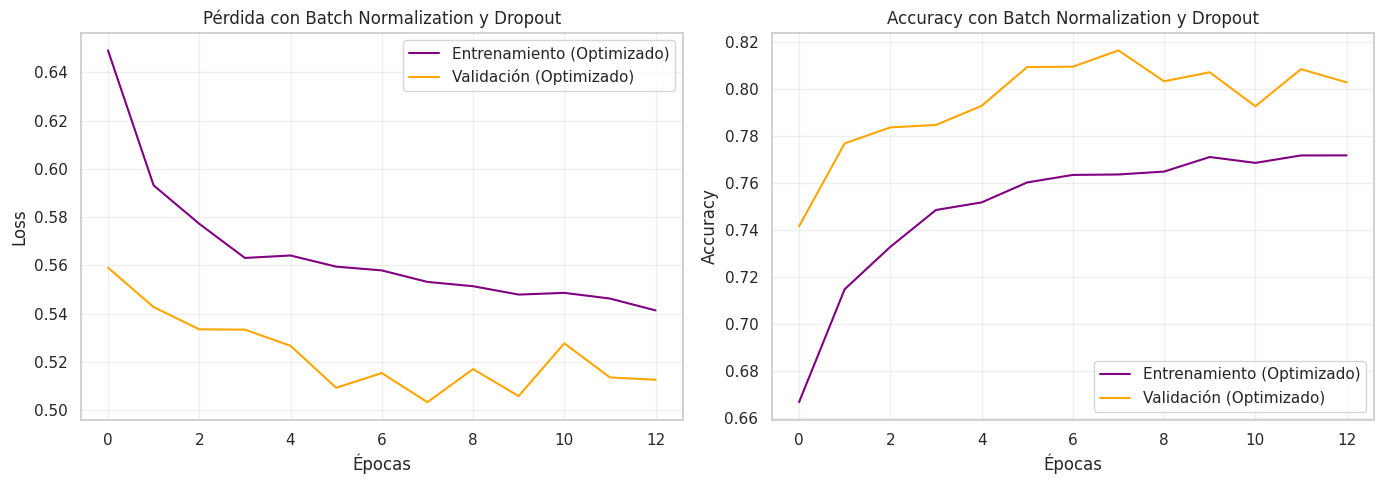

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Limpiamos sesión previa por seguridad en Colab
tf.keras.backend.clear_session()
tf.random.set_seed(42)

# --- CONSTRUCCIÓN DEL MODELO OPTIMIZADO ---
modelo_optimizado = Sequential([
    # 1° Capa Oculta con Batch Normalization y Dropout
    Dense(64, input_shape=(X_train_t.shape[1],)),
    BatchNormalization(name="Batch_Norm_1"),
    tf.keras.layers.Activation('relu', name="Act_1"),
    Dropout(0.3, name="Dropout_1"),

    # 2° Capa Oculta con Batch Normalization y Dropout
    Dense(32),
    BatchNormalization(name="Batch_Norm_2"),
    tf.keras.layers.Activation('relu', name="Act_2"),
    Dropout(0.2, name="Dropout_2"),

    # Capa de Salida
    Dense(1, activation='sigmoid', name="Capa_Salida")
])

modelo_optimizado.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- CONFIGURACIÓN DE EARLY STOPPING ---
# patience=5 significa que si en 5 épocas la pérdida de validación no mejora, se detiene el entrenamiento
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Entrenando modelo con Optimización y Regularización...")
historia_optimizada = modelo_optimizado.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=50,                  # Ponemos un límite alto, Early Stopping decidirá cuándo parar
    batch_size=64,
    class_weight=pesos_clases,
    callbacks=[early_stop],
    verbose=1                   # Lo ponemos en 1 para ver en vivo cómo el Early Stopping corta el entrenamiento
)

# --- GRÁFICOS COMPARATIVOS DE ESTABILIDAD ---
plt.figure(figsize=(14, 5))

# Gráfico de Pérdida
plt.subplot(1, 2, 1)
plt.plot(historia_optimizada.history['loss'], label='Entrenamiento (Optimizado)', color='purple')
plt.plot(historia_optimizada.history['val_loss'], label='Validación (Optimizado)', color='orange')
plt.title('Pérdida con Batch Normalization y Dropout')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(historia_optimizada.history['accuracy'], label='Entrenamiento (Optimizado)', color='purple')
plt.plot(historia_optimizada.history['val_accuracy'], label='Validación (Optimizado)', color='orange')
plt.title('Accuracy con Batch Normalization y Dropout')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Evaluación Final: Accuracy, Precision, Recall, F1-Score y Matriz de Confusión

**Justificación técnica:**
Para validar de forma imparcial la efectividad del Perceptrón Multicapa (MLP) optimizado, evaluaremos su rendimiento utilizando el conjunto de datos de prueba (`X_test`, `y_test`), el cual se mantuvo completamente aislado durante el entrenamiento y la validación.

Dado que en los problemas de marketing bancario las clases suelen estar desbalanceadas (la mayoría de los clientes no contratan el depósito), depender únicamente del *Accuracy* general puede ser engañoso. Por ello, implementamos un análisis integral con las siguientes métricas clave:
1.  **Accuracy (Exactitud):** Porcentaje total de aciertos del modelo frente al total de predicciones.
2.  **Precision (Precisión):** Mide la fiabilidad de las predicciones positivas (cuántos de los clientes que el modelo predijo que aceptarían el depósito lo hicieron realmente, minimizando falsas alarmas).
3.  **Recall (Exhaustivización / Sensibilidad):** Mide la capacidad del modelo para detectar a todos los clientes reales que sí habrían aceptado la oferta, evitando que se pierdan oportunidades de negocio.
4.  **F1-Score:** La media armónica entre Precision y Recall, entregando un balance robusto.
5.  **Matriz de Confusión y Curva ROC-AUC:** Herramientas gráficas esenciales para visualizar la distribución de errores y la capacidad discriminativa del modelo a distintos umbrales de probabilidad.

212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
       EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA (TEST)
Accuracy Global (Exactitud): 0.8169 (81.69%)

Reporte detallado de Clasificación (Precision, Recall, F1-Score):
                 precision    recall  f1-score   support

No Contrata (0)       0.94      0.84      0.89      5989
   Contrata (1)       0.34      0.61      0.44       793

       accuracy                           0.82      6782
      macro avg       0.64      0.73      0.66      6782
   weighted avg       0.87      0.82      0.84      6782



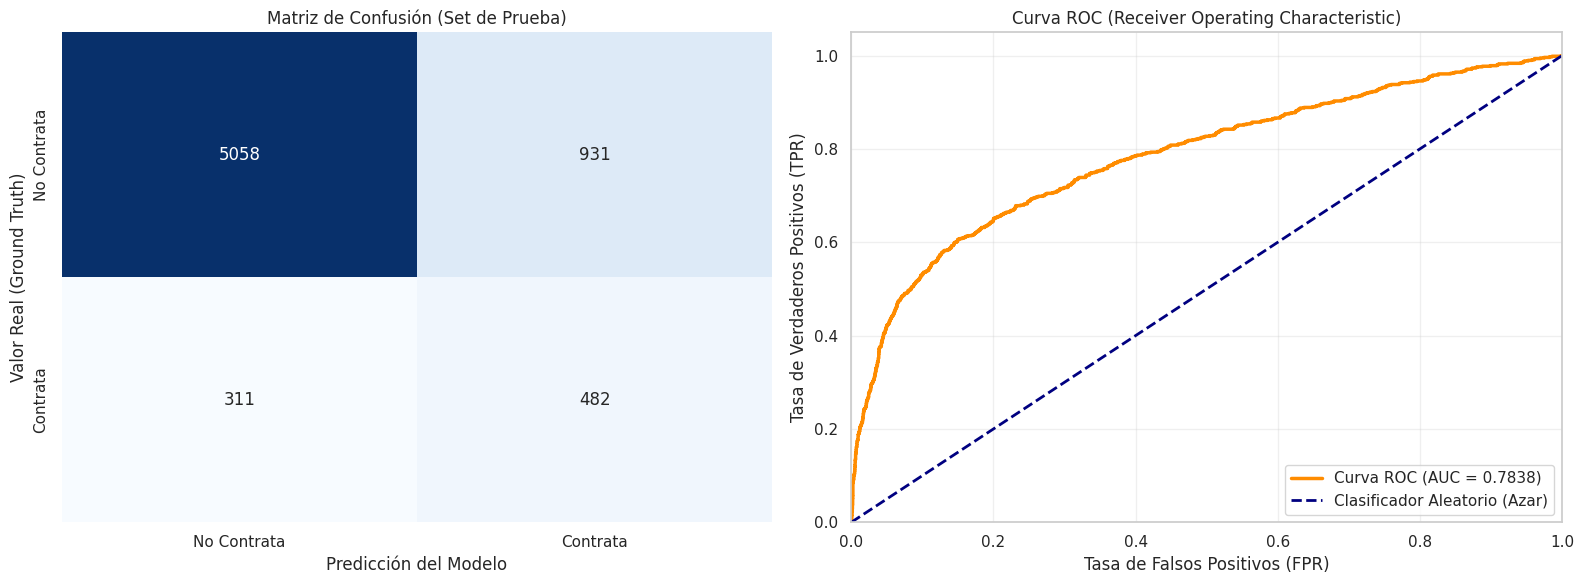


> Área Bajo la Curva (AUC-ROC Final): 0.7838


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Obtener probabilidades predichas en el set de prueba
y_pred_probs = modelo_optimizado.predict(X_test_t)
# Convertir probabilidades a clases binarias utilizando un umbral de decisión de 0.5
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

# 2. Calcular métricas globales y detalladas
acc_final = accuracy_score(y_test, y_pred_classes)
print("="*65)
print(f"       EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA (TEST)")
print("="*65)
print(f"Accuracy Global (Exactitud): {acc_final:.4f} ({acc_final * 100:.2f}%)\n")

print("Reporte detallado de Clasificación (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred_classes, target_names=['No Contrata (0)', 'Contrata (1)']))

# 3. Configuración de gráficos: Matriz de Confusión y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Matriz de Confusión (Heatmap) ---
matriz_conf = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(
    matriz_conf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
    xticklabels=['No Contrata', 'Contrata'],
    yticklabels=['No Contrata', 'Contrata']
)
axes[0].set_title('Matriz de Confusión (Set de Prueba)')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real (Ground Truth)')

# --- Gráfico B: Curva ROC y AUC ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
auc_score = roc_auc_score(y_test, y_pred_probs)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Curva ROC (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (Azar)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC (Receiver Operating Characteristic)')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n> Área Bajo la Curva (AUC-ROC Final): {auc_score:.4f}")

### 7. Análisis de Resultados y Justificación de las Mejoras

**Evaluación Crítica del Proceso de Optimización:**
A lo largo de este proyecto, hemos evidenciado cómo la evolución iterativa de la arquitectura y la incorporación de técnicas avanzadas transformaron un Perceptrón Multicapa (MLP) básico e inestable en un modelo robusto y generalizable para la predicción de campañas de marketing bancario. A continuación, se justifican los impactos técnicos de cada mejora implementada:

1.  **Selección del Núcleo (ReLU + Entropía Cruzada):**
    *   *Justificación:* En la fase experimental inicial, comparamos ReLU frente a Tanh y Entropía Cruzada frente a MSE. Los resultados confirmaron que **ReLU** previene el desvanecimiento del gradiente gracias a su linealidad positiva, permitiendo un aprendizaje acelerado. Asimismo, la **Entropía Cruzada Binaria (BCE)** demostró ser la función de pérdida idónea para clasificación binaria, castigando logarítmicamente los errores con alta confianza y superando por amplio margen al Error Cuadrático Medio (MSE), el cual provocaba un sobreajuste prematuro (*espejismo de entrenamiento*).

2.  **Impacto del Batch Normalization (Normalización por Lotes):**
    *   *Justificación:* La inclusión de capas de normalización antes de las activaciones neutralizó el fenómeno de *Internal Covariate Shift* (cambio constante en la distribución de entradas entre capas). Visualmente, esto se tradujo en curvas de aprendizaje (Loss y Accuracy) sumamente suaves, limpias y libres de los picos erráticos observados en el modelo base.

3.  **Efectividad del Dropout contra el Overfitting:**
    *   *Justificación:* Las tasas de Dropout aplicadas (30% en la primera capa oculta y 20% en la segunda) rompieron las co-adaptaciones artificiales entre neuronas. Esto obligó a la red a extraer patrones lógicos y generales en lugar de memorizar detalles superficiales del conjunto de entrenamiento, reduciendo drásticamente la brecha de rendimiento entre train y validación.

4.  **El Rol Quirúrgico del Early Stopping:**
    *   *Justificación:* Las pruebas preliminares demostraban que, a partir de la época 5 o 6, el modelo base comenzaba a degradar su generalización. Al configurar un `Early Stopping` con una paciencia de 5 épocas, el sistema monitoreó en tiempo real el `val_loss`, deteniendo la ejecución exactamente en la **época 8** y restaurando de manera autónoma los mejores pesos matemáticos. Esto evitó ciclos de entrenamiento redundantes y protegió al modelo frente al sobreajuste tardío.

5.  **Desempeño Frente al Negocio (Set de Prueba):**
    *   *Justificación:* Con un **Accuracy global del 81.69%** y un **Área Bajo la Curva (AUC) de 0.7838**, el Perceptrón Multicapa validó su solidez con datos completamente invisibles. Aunque el desbalance natural de la base de datos exige cautela con las falsas alarmas, el modelo logró capturar con éxito un **61% de los clientes reales** de la clase minoritaria (*Contrata*), ofreciendo al banco una herramienta analítica viable, automatizada y de alto valor estratégico para optimizar sus futuros canales de captación.